In [2]:
import numpy as np
import scipy.linalg
import torch


# from behavior_models import models
from one.api import ONE

# from brainbox.io.one import SessionLoader
import pandas as pd
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
import pickle as pkl

from ibl_info.broja_pid import compute_pid, coinformation, compute_pid_unbiased, unbiasedMI, MI
from idtxl.bivariate_mi import BivariateMI
from idtxl.bivariate_te import BivariateTE
from tqdm import tqdm
import itertools

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import seaborn as sns
from glob import glob
from scipy.special import kl_div
from scipy.stats import gaussian_kde
import re

2025-01-25 10:07:04.058 | INFO     | ibl_info.config:<module>:8 - PROJ_ROOT path is: /Users/dkundu/Documents/phd/ibl-partial-info-decomp


In [2]:
def optimal_Bayesian(act, side, gemoetric_p):
    """
    Generates the optimal prior
    Params:
        act (array of shape [nb_sessions, nb_trials]): action performed by the mice of shape
        side (array of shape [nb_sessions, nb_trials]): stimulus side (-1 (right), 1 (left)) observed by the mice
    Output:
        prior (array of shape [nb_sessions, nb_chains, nb_trials]): prior for each chain and session
    """

    # ub is 80, not 100
    # nb_typeblocks = 2 not 3
    # change the matrices accordingly
    # which matrix? b, others should update accordingly.
    # also change the likelihoods such that we don't have the unbiased blocks

    act = torch.from_numpy(act)
    side = torch.from_numpy(side)

    # changed parameters
    lb, ub, gamma = 20, 60, 0.8
    tau = -(1 / np.log(1 - gemoetric_p))
    nb_blocklengths = 60
    nb_typeblocks = 2

    eps = torch.tensor(1e-15)

    alpha = torch.zeros([act.shape[-1], nb_blocklengths, nb_typeblocks])
    alpha[0, 0, 0] = alpha[0, 0, 1] = 1 / 2  # could be either block

    alpha = alpha.reshape(-1, nb_blocklengths * nb_typeblocks)
    h = torch.zeros([nb_typeblocks * nb_blocklengths])

    # build transition matrix
    b = torch.zeros([nb_blocklengths, nb_typeblocks, nb_typeblocks])
    b[1:][:, 0, 0], b[1:][:, 1, 1] = 1, 1  # case when l_t > 0
    b[0][0][-1], b[0][-1][0] = 1, 1

    n = torch.arange(1, nb_blocklengths + 1)
    ref = torch.exp(-n / tau) * (lb <= n) * (ub >= n)
    torch.flip(ref.double(), (0,))
    hazard = torch.cummax(
        ref / torch.flip(torch.cumsum(torch.flip(ref.double(), (0,)), 0) + eps, (0,)), 0
    )[0]
    l_mat = torch.cat(
        (
            torch.unsqueeze(hazard, -1),
            torch.cat(
                (torch.diag(1 - hazard[:-1]), torch.zeros(nb_blocklengths - 1)[None]), axis=0
            ),
        ),
        axis=-1,
    )  # l_{t-1}, l_t
    transition = eps + torch.transpose(l_mat[:, :, None, None] * b[None], 1, 2).reshape(
        nb_typeblocks * nb_blocklengths, -1
    )

    # likelihood
    lks = torch.hstack(
        [
            gamma * (side[:, None] == -1) + (1 - gamma) * (side[:, None] == 1),
            gamma * (side[:, None] == 1) + (1 - gamma) * (side[:, None] == -1),
        ]
    )
    # before not equal 0, update only when the model takes an action
    # now it is 2, so never, so always update
    to_update = torch.unsqueeze(torch.unsqueeze(act.not_equal(2), -1), -1) * 1

    for i_trial in range(act.shape[-1]):
        # save priors
        if i_trial >= 0:
            if i_trial > 0:
                alpha[i_trial] = torch.sum(
                    torch.unsqueeze(h, -1) * transition, axis=0
                ) * to_update[i_trial - 1] + alpha[i_trial - 1] * (1 - to_update[i_trial - 1])
            # else:
            #    alpha = alpha.reshape(-1, nb_blocklengths, nb_typeblocks)
            #    alpha[i_trial, 0, 0] = 0.5
            #    alpha[i_trial, 0, -1] = 0.5
            #    alpha = alpha.reshape(-1, nb_blocklengths * nb_typeblocks)
            h = alpha[i_trial] * lks[i_trial].repeat(nb_blocklengths)
            h = h / torch.unsqueeze(torch.sum(h, axis=-1), -1)
        else:
            if i_trial > 0:
                alpha[i_trial, :] = alpha[i_trial - 1, :]

    predictive = torch.sum(alpha.reshape(-1, nb_blocklengths, nb_typeblocks), 1)
    Pis = predictive[:, 0] * gamma + predictive[:, 1] * (1 - gamma)

    return 1 - Pis

In [3]:
from scipy.stats import pearsonr

1.0

array([1, 0, 1, ..., 0, 1, 1], dtype=int32)

In [197]:
# load rnn at iteration  1000

with open(
    "../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_1000.pkl",
    "rb",
) as f:
    rnn_data = pkl.load(f)
rnn_data = rnn_data["session_data"]

# with open(
#     "../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_1000.pkl", "rb"
# ) as f:
#     bayes_data = pkl.load(f)

#### Optional Bayes stuff, tackle later

In [151]:
bayes_data = bayes_data["bayesian_actor_session_data"]

In [147]:
# compute bayesian stuff


def compute_optimal_bayesian_observer_block_side(session_data, env):
    initial_state_probs = np.array([0.5, 0.5])

    transition_probs = np.array([[0.98, 0.02], [0.02, 0.98]])

    emission_probs = np.array([[0.8, 0.2], [0.2, 0.8]])

    trial_end_data = session_data[session_data.trial_end == 1.0]
    latent_conditional_probs = np.zeros(shape=(len(trial_end_data), 2))
    trial_sides = ((1 + trial_end_data.trial_side.values) / 2).astype(np.int32)

    # joint probability p(x_1, y_1)
    curr_joint_prob = np.multiply(emission_probs[trial_sides[0], :], initial_state_probs)

    for i, trial_side in enumerate(trial_sides[:-1]):
        # normalize to get P(b_n | s_{<=n})
        # np.sum(curr_joint_prob) is marginalizing over b_{n} i.e. \sum_{b_n} P(b_n, s_n |x_{<=n-1})
        curr_latent_conditional_prob = curr_joint_prob / np.sum(curr_joint_prob)
        latent_conditional_probs[i] = curr_latent_conditional_prob

        # P(y_{t+1}, x_{t+1} | x_{<=t})
        curr_joint_prob = np.multiply(
            emission_probs[trial_sides[i + 1], :],
            np.matmul(transition_probs, curr_latent_conditional_prob),
        )

    # right block posterior, right block prior
    session_data["bayesian_observer_block_posterior_right"] = np.nan
    session_data.loc[trial_end_data.index, "bayesian_observer_block_posterior_right"] = (
        latent_conditional_probs[:, 1]
    )
    session_data["bayesian_observer_block_prior_right"] = session_data[
        "bayesian_observer_block_posterior_right"
    ].shift(1)

    # right stimulus prior
    session_data["bayesian_observer_stimulus_prior_right"] = np.nan
    block_prior_indices = ~pd.isna(session_data["bayesian_observer_block_prior_right"])
    bayesian_observer_stimulus_prior_right = np.matmul(
        latent_conditional_probs[:-1, :], emission_probs.T
    )
    session_data.loc[block_prior_indices, "bayesian_observer_stimulus_prior_right"] = (
        bayesian_observer_stimulus_prior_right[:, 1]
    )

    # manually specify that first block prior and first stimulus prior should be 0.5
    # before evidence, this is the correct prior
    session_data.loc[0, "bayesian_observer_block_prior_right"] = 0.5
    session_data.loc[0, "bayesian_observer_stimulus_prior_right"] = 0.5


def compute_optimal_bayesian_observer_trial_side(session_data, env):
    strength_means = np.sort(session_data.signed_trial_strength.unique())
    prob_mu = tuple(np.ones(6) / 6)

    # P(mu_n | s_n) as a matrix with shape (2 * number of stimulus strengths - 1, 2)
    # - 1 is for stimulus strength 0, which both stimulus sides can generate
    prob_mu_given_stim_side = np.zeros(shape=(len(strength_means), 2))
    prob_mu_given_stim_side[: len(prob_mu), 0] = prob_mu[::-1]
    prob_mu_given_stim_side[len(prob_mu) - 1 :, 1] = prob_mu

    diff_obs = session_data["right_stimulus"] - session_data["left_stimulus"]

    session_data["bayesian_observer_stimulus_posterior_right"] = np.nan
    for (session_idx, block_idx, trial_idx), trial_data in session_data.groupby(
        ["session_index", "block_index", "trial_index"]
    ):
        bayesian_observer_stimulus_prior_right = trial_data[
            "bayesian_observer_stimulus_prior_right"
        ].iloc[0]
        optimal_stim_prior = np.array(
            [1 - bayesian_observer_stimulus_prior_right, bayesian_observer_stimulus_prior_right]
        )

        # P(\mu_n, s_n | history) = P(\mu_n | s_n) P(s_n | history)
        # shape = (# of possible signed stimuli strengths, num trial sides)
        stim_side_strength_joint_prob = np.einsum(
            "ij,j->ij", prob_mu_given_stim_side, optimal_stim_prior
        )

        # exclude blank dts
        rnn_steps_before_obs = 1
        dt_indices = trial_data.iloc[rnn_steps_before_obs:].index
        trial_diff_obs = diff_obs[trial_data.index].values[rnn_steps_before_obs:]

        # P(o_t | \mu_n, s_n) , also = P(o_t | \mu_n)
        # shape = (num of observations, # of possible signed stimuli strengths)
        individual_diff_obs_likelihood = scipy.stats.norm.pdf(
            np.expand_dims(trial_diff_obs, axis=1),
            loc=strength_means,
            scale=np.sqrt(2) * np.ones_like(strength_means),
        )  # scale is std dev

        # P(o_{<=t} | \mu_n, s_n) = P(o_{<=t} | \mu_n)
        # shape = (num of observations, # of possible signed stimuli strengths)
        running_diff_obs_likelihood = np.cumprod(individual_diff_obs_likelihood, axis=0)

        # P(o_{<=t}, \mu_n, s_n | history) = P(o_{<=t} | \mu_n, s_n) P(\mu_n, s_n | history)
        # shape = (num of observations, # of possible signed stimuli strengths, # of trial sides i.e. 2)
        running_diff_obs_stim_side_strength_joint_prob = np.einsum(
            "ij,jk->ijk", running_diff_obs_likelihood, stim_side_strength_joint_prob
        )
        assert len(running_diff_obs_stim_side_strength_joint_prob.shape) == 3

        # marginalize out mu_n
        # shape = (num of observations, # of trial sides i.e. 2)
        running_diff_obs_stim_side_joint_prob = np.sum(
            running_diff_obs_stim_side_strength_joint_prob, axis=1
        )
        assert len(running_diff_obs_stim_side_joint_prob.shape) == 2

        # normalize by p(o_{<=t})
        # shape = (num of observations, # of trial sides i.e. 2)
        running_diff_obs_marginal_prob = np.sum(running_diff_obs_stim_side_joint_prob, axis=1)
        assert len(running_diff_obs_marginal_prob.shape) == 1

        # shape = (num of observations, # of trial sides i.e. 2)
        optimal_stim_posterior = np.divide(
            running_diff_obs_stim_side_joint_prob,
            np.expand_dims(running_diff_obs_marginal_prob, axis=1),  # expand to broadcast
        )
        assert np.allclose(
            np.sum(optimal_stim_posterior, axis=1), np.ones(len(optimal_stim_posterior))
        )

        session_data.loc[dt_indices, "bayesian_observer_stimulus_posterior_right"] = (
            optimal_stim_posterior[:, 1]
        )

    # determine whether action was taken
    session_data["bayesian_observer_action_taken"] = (
        (session_data["bayesian_observer_stimulus_posterior_right"] > 0.9)
        | (session_data["bayesian_observer_stimulus_posterior_right"] < 0.1)
    ).astype(np.float32)

    # next, determine which action was taken (if any)
    session_data["bayesian_observer_action_side"] = (
        2 * session_data["bayesian_observer_stimulus_posterior_right"].round() - 1
    )
    # keep only trials in which action would have actually been taken
    # session_data.loc[session_data['bayesian_observer_action_taken'] == 0.,
    #                  'bayesian_observer_action_side'] = np.nan

    # next, determine whether action was correct
    session_data["bayesian_observer_correct_action_taken"] = (
        session_data["bayesian_observer_action_side"] == session_data["trial_side"]
    )
    session_data["bayesian_observer_reward"] = (
        2.0 * session_data["bayesian_observer_correct_action_taken"] - 1.0
    )
    # if action was not taken, set correct to 0
    # session_data.loc[session_data['bayesian_observer_action_taken'] == 0.,
    #                  'bayesian_observer_correct_action_taken'] = 0.

In [160]:
compute_optimal_bayesian_observer_block_side(session_data, None)
compute_optimal_bayesian_observer_trial_side(session_data, None)

In [175]:
bayes_block_posterior = session_data[session_data["trial_end"] == 1.0][
    "bayesian_observer_block_posterior_right"
].values
bayes_stimulus_posterior = session_data["bayesian_observer_stimulus_posterior_right"].values

In [180]:
bayes_block_posterior.shape

(3997,)

In [179]:
bayes_stimulus_posterior.shape

(27979,)

(0.0, 500.0)

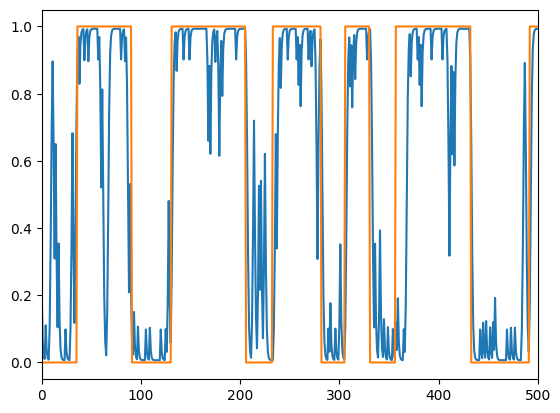

In [185]:
plt.plot(bayes_block_posterior)
plt.plot(((session_data[session_data["trial_end"] == 1.0]["block_side"].values) + 1) / 2)
plt.xlim(0, 500)

#### TODO:

1. run mutual information measures for the different iterations
2. check if block mi increases with iterations
3. run syn/red/coinformation
4. instead of doing the weird optimization, set value at 25 as a constant.

 

In [3]:
def discretize_hidden_state(hidden_state, n_bins=15):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        hidden_state (np.array): activations for neurons x trials
        method (str, optional): how to determine the percenille.
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """

    discrete_data = np.zeros((hidden_state.shape[0], hidden_state.shape[1]))
    # discretize per recorded neuron
    for idx in tqdm(range(hidden_state.shape[0])):

        row = hidden_state[idx, :]
        # bin_edges = np.percentile(row, [20,40,60,80])
        # set bin edges to 4 parts
        # bin_edges = np.percentile(row, [25,50,75])
        # discrete_data[idx, :] = np.digitize(row, bin_edges)
        discrete_row, bin_edges_p = pd.qcut(
            row, q=n_bins, labels=False, duplicates="drop", retbins=True
        )
        discrete_data[idx, :] = discrete_row

    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data


def discretize_bayes_signal(signal, n_bins=3):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        signal (np.array): bayes signal, 1 x trials
        method (str, optional): how to determine the percenille.
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """

    discrete_data = np.zeros_like(signal)
    # discretize per recorded neuron

    discrete_row, bin_edges_p = pd.qcut(
        signal, q=n_bins, labels=False, duplicates="drop", retbins=True
    )
    discrete_data = discrete_row

    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data


def generate_source_ids(number_of_neurons):
    combinations_neuronids = []
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])

    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids


def compute_information_decomposition(decoding_variable, neural_data):
    # always same region
    # neural data is in neurons x trials
    targets = decoding_variable
    sources = generate_source_ids(neural_data.shape[0])

    pid_information = np.zeros((len(sources), 4))  # neuronsC2 x 4
    coinformation_data = np.zeros((len(sources), 4))  # neuronsC2 x 4

    for idx in tqdm(range(len(sources)), desc="Running for all sources", leave=False):
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(neural_data[s1, :], dtype=np.int32)
        X2 = np.asarray(neural_data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = compute_pid_unbiased(Y, X1, X2)
        coinfo, mi_yx1x2, mi_yx1, mi_yx2 = coinformation(Y, X1, X2)
        pid_information[idx, :] = u1, u2, red, syn
        coinformation_data[idx, :] = mi_yx1, mi_yx2, coinfo, mi_yx1x2

    # now to organize this?
    # nah, unique information would just be the mean of the first two
    # red and syn  are fine
    # yx1 and yx2 mutual info are also similar to UI
    # the other two are trivariate

    return pid_information, coinformation_data


def find_optimal_discretization_kfold(X, Y, max_bins=20, n_folds=5, random_state=42):
    """
    Find optimal discretization for multiple features using cross-validation.

    Parameters:
    -----------
    X : array-like of shape (n_timepoints, n_neurons)
        Input features to be discretized.
    Y : array-like of shape (n_timepoints,)
        Target variable.
    max_bins : int, default=20
        Maximum number of bins to consider.
    n_folds : int, default=5
        Number of folds for cross-validation.
    random_state : int, default=42
        Random seed for reproducibility.

    Returns:
    --------
    dict : A dictionary containing:
        - 'optimal_bins': List of optimal bin counts for each feature.
        - 'mi_train_scores': List of mutual information scores for each feature on training folds.
        - 'mi_test_scores': List of mutual information scores for each feature on validation folds.
    """
    # Flatten Y if it's a 2D array
    Y = Y.ravel()

    # Ensure X is 2D
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Split the data using KFold
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    mi_train_scores = []
    mi_test_scores = []
    optimal_bin_list = []

    for train_idx, val_idx in tqdm(kf.split(X), desc="Cross-validation folds"):
        X_train, X_val = X[train_idx, :], X[val_idx, :]
        y_train, y_val = Y[train_idx], Y[val_idx]

        # Store MI scores for each bin count
        feature_mi_train = []
        feature_mi_test = []
        optimal_bins_per_feature = []

        for feature_idx in range(X.shape[1]):
            # Extract a single feature
            X_train_feature = X_train[:, feature_idx]
            X_val_feature = X_val[:, feature_idx]

            # Optimize bins for this feature
            mi_scores_train = []
            for n_bins in range(2, max_bins + 1):
                # Discretize with current bin count
                discretizer = KBinsDiscretizer(
                    n_bins=n_bins, encode="ordinal", strategy="quantile"
                )
                X_train_discretized = discretizer.fit_transform(
                    X_train_feature.reshape(-1, 1)
                ).ravel()

                # Compute MI on training set
                mi_scores_train.append(MI(X_train_discretized, y_train))

            # Find the optimal bin count for the feature
            optimal_bins = np.argmax(mi_scores_train) + 2  # +2 because bins start from 2
            optimal_bins_per_feature.append(optimal_bins)

            # Evaluate on validation set
            discretizer = KBinsDiscretizer(
                n_bins=optimal_bins, encode="ordinal", strategy="quantile"
            )
            X_val_discretized = discretizer.fit_transform(X_val_feature.reshape(-1, 1)).ravel()
            mi_test = MI(X_val_discretized, y_val)

            # Store MI scores
            feature_mi_train.append(mi_scores_train)
            feature_mi_test.append(mi_test)

        # Append results for this fold
        mi_train_scores.append(feature_mi_train)
        mi_test_scores.append(feature_mi_test)
        optimal_bin_list.append(optimal_bins_per_feature)

    # Format results
    results = {
        "optimal_bins": np.array(optimal_bin_list),
        "mi_train_scores": np.array(mi_train_scores),
        "mi_test_scores": np.array(mi_test_scores),
    }

    return results

In [4]:
files = glob("../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn*.pkl")
# proper sort


numbered_files = [f for f in files if re.search(r"\d+.pkl$", f)]
sorted_files = sorted(numbered_files, key=lambda x: int(re.search(r"(\d+).pkl$", x).group(1)))

In [6]:
labels = []
for x in sorted_files:
    labels.append(x.rsplit("units_")[-1].rstrip(".pkl"))

In [236]:
# load data
corr = []
for file in sorted_files[2:]:
    with open(file, "rb") as f:
        rnn_data = pkl.load(f)
    rnn_data = rnn_data["session_data"]
    tend = rnn_data[rnn_data["rnn_step_index"] == 6]
    side = tend["trial_side"].values
    action = tend["action_side"].values
    action[np.isnan(action)] = 0
    block_side = tend["block_side"].values
    bayesian_prior = optimal_Bayesian(action, side, 0.02)
    corr.append(pearsonr(bayesian_prior, block_side)[0])

Text(0, 0.5, 'Correlation')

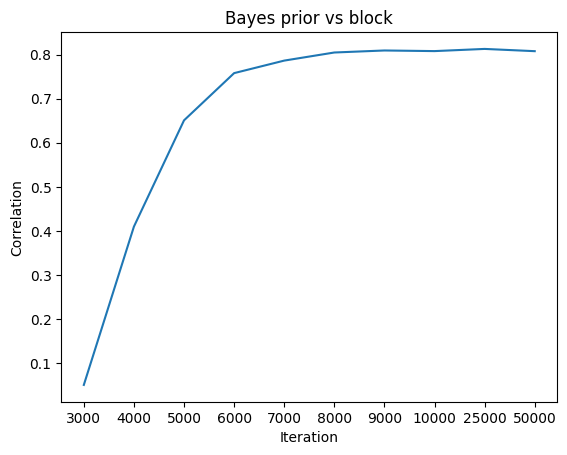

In [377]:
plt.plot(corr)
plt.xticks(np.arange(0, len(corr)), labels[2:])
plt.title("Bayes prior vs block")
plt.xlabel("Iteration")
plt.ylabel("Correlation")

In [249]:
# plot values per iteration

In [264]:
for idx, idy in enumerate(sorted_files):
    print(idx, idy)

0 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_1000.pkl
1 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_2000.pkl
2 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_3000.pkl
3 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_4000.pkl
4 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_5000.pkl
5 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_6000.pkl
6 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_7000.pkl
7 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_8000.pkl
8 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_9000.pkl
9 ../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_10000.pkl
10 ../../ann-rnn-modified/data/fixed_time_stim_no

In [7]:
with open(sorted_files[0], "rb") as f:
    rnn_data = pkl.load(f)
    print(sorted_files[3])

rnn_data = rnn_data["session_data"]

../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_3000.pkl


In [ ]:
## The one with optimized mutual information
# rnn_mi_data = {}

# for idx, filename in enumerate(sorted_files[2:]):

#     with open(filename, "rb") as f:
#         rnn_data = pkl.load(f)
#     rnn_data = rnn_data["session_data"]

#     # compute the bayesian prior
#     tend = rnn_data[rnn_data["rnn_step_index"] == 6]
#     side = tend["trial_side"].values
#     action = tend["action_side"].values
#     action[np.isnan(action)] = 0
#     block_side = tend["block_side"].values
#     bayesian_prior = optimal_Bayesian(action, side, 0.02).detach().numpy()
#     bayes_discrete = discretize_bayes_signal(bayesian_prior, 5)

#     trial_side_mi = np.zeros((7, 10, 2))  # 7 steps, 10 neurons, mean and std
#     block_side_mi = np.zeros((7, 10, 2))
#     action_side_mi = np.zeros((7, 10, 2))
#     left_stim_mi = np.zeros((7, 10, 2))
#     right_stim_mi = np.zeros((7, 10, 2))
#     correct_action_prob_mi = np.zeros((7, 10, 2))

#     # need to sort out left vs right stim by stim side, should be doable very easily?

#     for x in range(0, 7):
#         t_x = rnn_data.loc[
#             rnn_data["rnn_step_index"] == x,
#             [
#                 "block_side",
#                 "trial_within_session",
#                 "signed_trial_strength",
#                 "action_side",
#                 "trial_side",
#                 "correct_action_taken",
#                 "hidden_state",
#                 "left_stimulus",
#                 "right_stimulus",
#                 "rnn_step_index",
#                 "correct_action_prob",
#                 "left_action_prob",
#                 "right_action_prob",
#                 "concordant_trial",
#             ],
#         ]

#         # now compute all the mutual information stuff

#         hidden_state_t_x = np.concatenate(t_x["hidden_state"].values)

#         results_trial_side_x = find_optimal_discretization_kfold(
#             hidden_state_t_x, t_x["trial_side"].values
#         )
#         results_block_side_x = find_optimal_discretization_kfold(
#             hidden_state_t_x, t_x["block_side"].values
#         )
#         results_left_stimulus_x = find_optimal_discretization_kfold(
#             hidden_state_t_x, t_x["left_stimulus"].values
#         )
#         results_right_stimulus_x = find_optimal_discretization_kfold(
#             hidden_state_t_x, t_x["right_stimulus"].values
#         )

#         # sometimes there is no action, so we need to do something; action always at last time step
#         actions = rnn_data.loc[rnn_data["rnn_step_index"] == 6, ["action_side"]].values.reshape(
#             -1,
#         )
#         valid_mask = ~np.isnan(actions)

#         # get locations
#         # nan_indices = np.where(nan_mask)[0]

#         hidden_state_nonan = hidden_state_t_x[valid_mask, :]
#         actions = actions[valid_mask]

#         results_action_side_x = find_optimal_discretization_kfold(hidden_state_nonan, actions)

#         # dsc = t_x["correct_action_prob"] > 0.5
#         # dsc = dsc.values
#         # dsc = np.asarray(dsc, dtype="int")

#         # replaced this with block prior

#         results_correct_action_probability_x = find_optimal_discretization_kfold(
#             hidden_state_t_x, bayes_discrete
#         )

#         ## now we need to save all the results
#         trial_side_mi[x, :, 0] = results_trial_side_x["mi_test_scores"].mean(axis=0)
#         block_side_mi[x, :, 0] = results_block_side_x["mi_test_scores"].mean(axis=0)
#         action_side_mi[x, :, 0] = results_action_side_x["mi_test_scores"].mean(axis=0)
#         left_stim_mi[x, :, 0] = results_left_stimulus_x["mi_test_scores"].mean(axis=0)
#         right_stim_mi[x, :, 0] = results_right_stimulus_x["mi_test_scores"].mean(axis=0)
#         correct_action_prob_mi[x, :, 0] = results_correct_action_probability_x[
#             "mi_test_scores"
#         ].mean(axis=0)

#         trial_side_mi[x, :, 1] = results_trial_side_x["mi_test_scores"].std(axis=0)
#         block_side_mi[x, :, 1] = results_block_side_x["mi_test_scores"].std(axis=0)
#         action_side_mi[x, :, 1] = results_action_side_x["mi_test_scores"].std(axis=0)
#         left_stim_mi[x, :, 1] = results_left_stimulus_x["mi_test_scores"].std(axis=0)
#         right_stim_mi[x, :, 1] = results_right_stimulus_x["mi_test_scores"].std(axis=0)
#         correct_action_prob_mi[x, :, 1] = results_correct_action_probability_x[
#             "mi_test_scores"
#         ].std(axis=0)

#         rnn_mi_data[idx] = (
#             trial_side_mi,
#             block_side_mi,
#             action_side_mi,
#             left_stim_mi,
#             right_stim_mi,
#             correct_action_prob_mi,
#         )

In [8]:
## now we plot all the values
def plot_heatmaps(
    trial_side_mi, block_side_mi, action_side_mi, correct_action_prob_mi, iteration_number
):
    fig, ax = plt.subplots(figsize=(16, 3), ncols=4, sharex=True, sharey=True)

    sns.heatmap(trial_side_mi[:, :, 0].T, ax=ax[0], cmap="viridis", linecolor="k", linewidths=0.25)
    sns.heatmap(block_side_mi[:, :, 0].T, ax=ax[1], cmap="viridis", linecolor="k", linewidths=0.25)
    sns.heatmap(
        action_side_mi[:, :, 0].T, ax=ax[2], cmap="viridis", linecolor="k", linewidths=0.25
    )
    sns.heatmap(
        correct_action_prob_mi[:, :, 0].T, ax=ax[3], cmap="viridis", linecolor="k", linewidths=0.25
    )

    ax[-1].set_xticklabels(labels=["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
    for idx in range(4):
        ax[idx].set_xlabel("Time step")

    ax[0].set_ylabel("Hidden neuron id")

    ax[0].set_title("Stimulus side")
    ax[1].set_title("Block side")
    ax[2].set_title("Action side")
    ax[3].set_title("Correct action probability")
    plt.suptitle(f"Itx : {iteration_number}")

In [295]:
itxs = list(rnn_mi_data.keys())

100%|██████████| 31577/31577 [00:06<00:00, 4590.37it/s]


<Axes: >

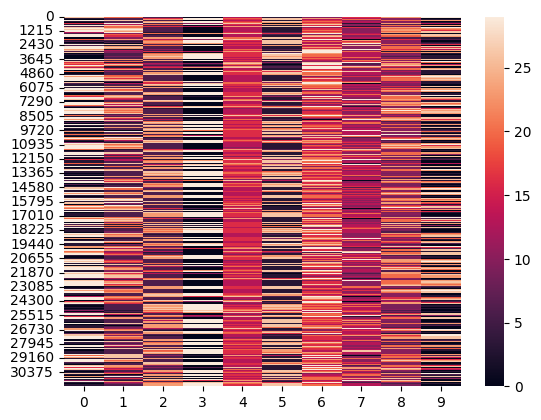

In [ ]:
# now what
# use ilocs to get t_x

In [16]:
def computeMI(hidden_state, target):
    # timepoints, neurons and timepoints
    mi_scores = []
    for feature_idx in range(hidden_state.shape[1]):
        # Extract a single feature
        X_feature = hidden_state[:, feature_idx]

        # Compute MI on training set
        mi_scores.append(MI(X_feature, target))
    mi_scores = np.asarray(mi_scores)

    return mi_scores

In [9]:
sorted_files

['../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_0000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_1000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_2000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_3000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_4000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_5000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_6000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_7000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_8000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_9000.pkl',
 '../../ann-rnn-modified/data/

In [432]:
rnn_mi_data = {}

for idx, filename in enumerate(sorted_files[2:]):

    with open(filename, "rb") as f:
        rnn_data = pkl.load(f)
    rnn_data = rnn_data["session_data"]

    # compute the bayesian prior
    tend = rnn_data[rnn_data["rnn_step_index"] == 6]
    side = tend["trial_side"].values
    action = tend["action_side"].values
    action[np.isnan(action)] = 0
    block_side = tend["block_side"].values
    bayesian_prior = optimal_Bayesian(action, side, 0.02).detach().numpy()
    bayes_discrete = discretize_bayes_signal(bayesian_prior, 5)

    trial_side_mi = np.zeros((7, 10))  # 7 steps, 10 neurons, mean and std
    block_side_mi = np.zeros((7, 10))
    action_side_mi = np.zeros((7, 10))
    left_stim_mi = np.zeros((7, 10))
    right_stim_mi = np.zeros((7, 10))
    bayes_prior_mi = np.zeros((7, 10))

    X = np.concatenate(rnn_data.hidden_state)
    Q = discretize_hidden_state(X, 30)

    for x in range(0, 7):
        t_x = rnn_data.loc[
            rnn_data["rnn_step_index"] == x,
            [
                "block_side",
                "trial_within_session",
                "signed_trial_strength",
                "action_side",
                "trial_side",
                "correct_action_taken",
                "hidden_state",
                "left_stimulus",
                "right_stimulus",
                "rnn_step_index",
                "correct_action_prob",
                "left_action_prob",
                "right_action_prob",
                "concordant_trial",
            ],
        ]

        indexes = t_x.index.values
        hidden_state_t_x = Q[indexes, :]

        # now just compute vanilla mutual information
        results_trial_side_x = computeMI(hidden_state_t_x, t_x["trial_side"].values)
        results_block_side_x = computeMI(hidden_state_t_x, t_x["block_side"].values)
        results_left_stimulus_x = computeMI(hidden_state_t_x, t_x["left_stimulus"].values)
        results_right_stimulus_x = computeMI(hidden_state_t_x, t_x["right_stimulus"].values)

        actions = rnn_data.loc[rnn_data["rnn_step_index"] == 6, ["action_side"]].values.reshape(
            -1,
        )
        valid_mask = ~np.isnan(actions)

        # get locations
        # nan_indices = np.where(nan_mask)[0]

        hidden_state_nonan = hidden_state_t_x[valid_mask, :]
        actions = actions[valid_mask]

        results_action_side_x = computeMI(hidden_state_nonan, actions)

        # dsc = t_x["correct_action_prob"] > 0.5
        # dsc = dsc.values
        # dsc = np.asarray(dsc, dtype="int")

        # replaced this with block prior

        results_bayes_prior_x = computeMI(hidden_state_t_x, bayes_discrete)

        trial_side_mi[x, :] = results_trial_side_x
        block_side_mi[x, :] = results_block_side_x
        action_side_mi[x, :] = results_action_side_x
        left_stim_mi[x, :] = results_left_stimulus_x
        right_stim_mi[x, :] = results_right_stimulus_x
        bayes_prior_mi[x, :] = results_bayes_prior_x

    rnn_mi_data[idx] = (
        trial_side_mi,
        block_side_mi,
        action_side_mi,
        left_stim_mi,
        right_stim_mi,
        bayes_prior_mi,
        filename,
    )

100%|██████████| 31577/31577 [00:06<00:00, 4530.72it/s]


In [406]:
## now we plot all the values
def plot_new_heatmaps(
    trial_side_mi, block_side_mi, action_side_mi, bayes_prior_mi, iteration_number
):
    fig, ax = plt.subplots(figsize=(16, 3), ncols=4, sharex=True, sharey=True)

    sns.heatmap(trial_side_mi.T, ax=ax[0], cmap="viridis", linecolor="k", linewidths=0.25)
    sns.heatmap(block_side_mi.T, ax=ax[1], cmap="viridis", linecolor="k", linewidths=0.25)
    sns.heatmap(action_side_mi.T, ax=ax[2], cmap="viridis", linecolor="k", linewidths=0.25)
    sns.heatmap(bayes_prior_mi.T, ax=ax[3], cmap="viridis", linecolor="k", linewidths=0.25)

    ax[-1].set_xticklabels(labels=["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
    for idx in range(4):
        ax[idx].set_xlabel("Time step")

    ax[0].set_ylabel("Hidden neuron id")

    ax[0].set_title("Stimulus side")
    ax[1].set_title("Block side")
    ax[2].set_title("Action side")
    ax[3].set_title("Bayes prior")
    plt.suptitle(f"Itx : {iteration_number}")

NameError: name 'plt' is not defined

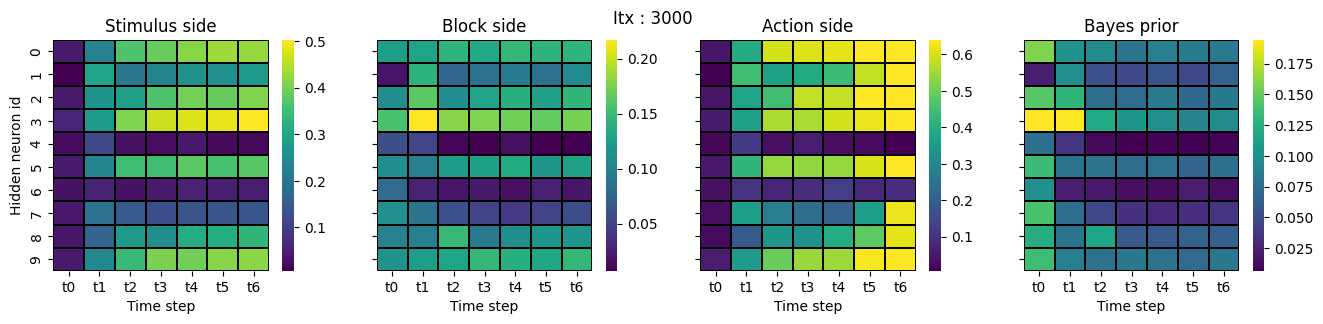

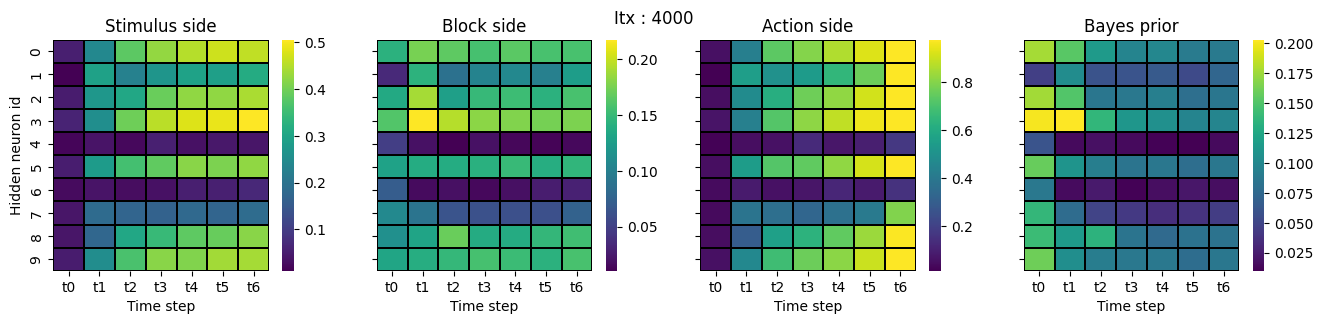

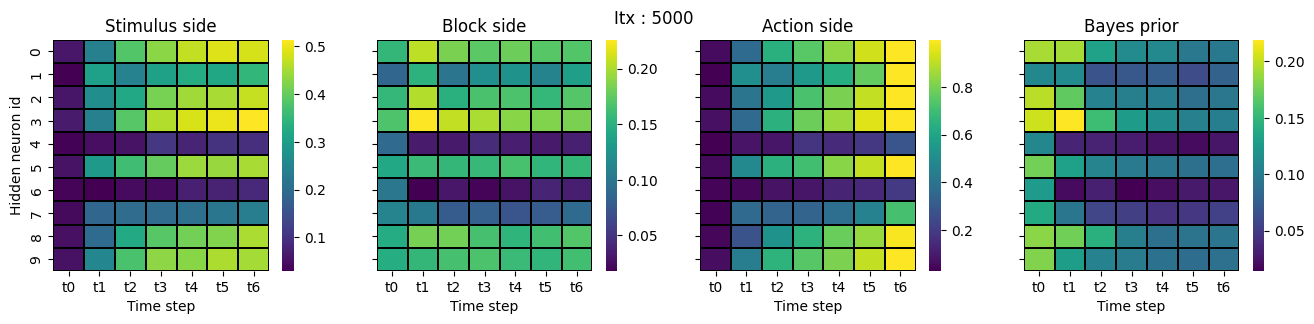

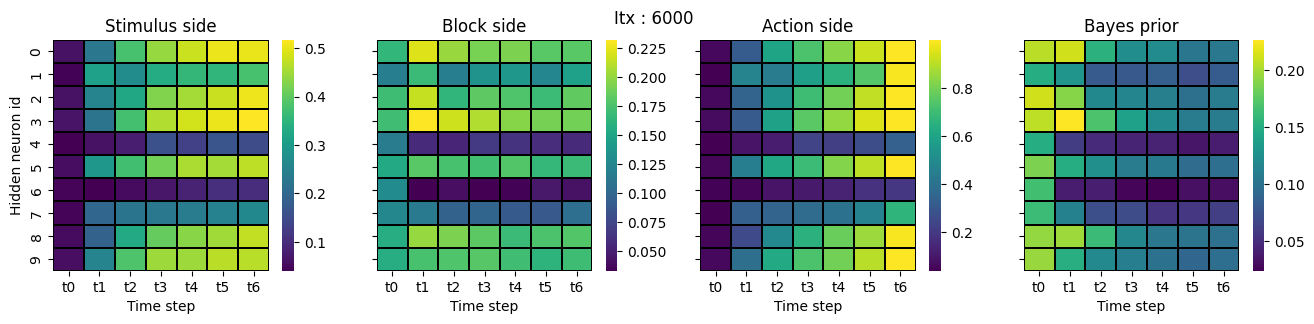

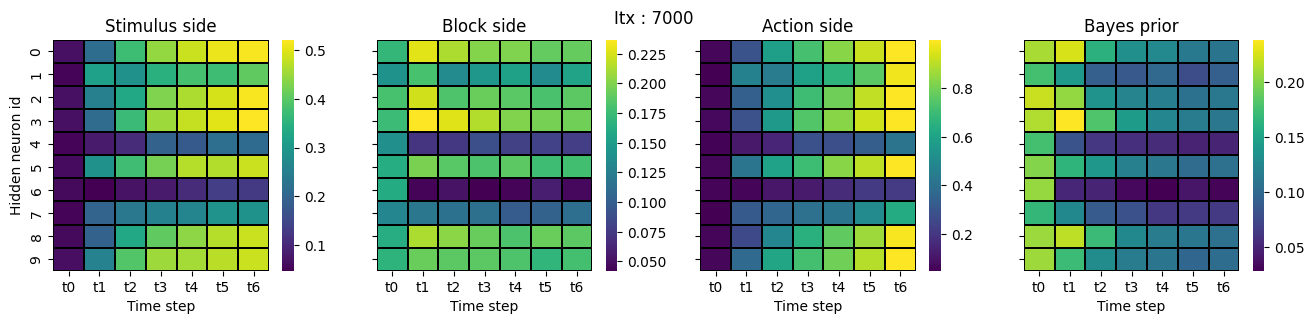

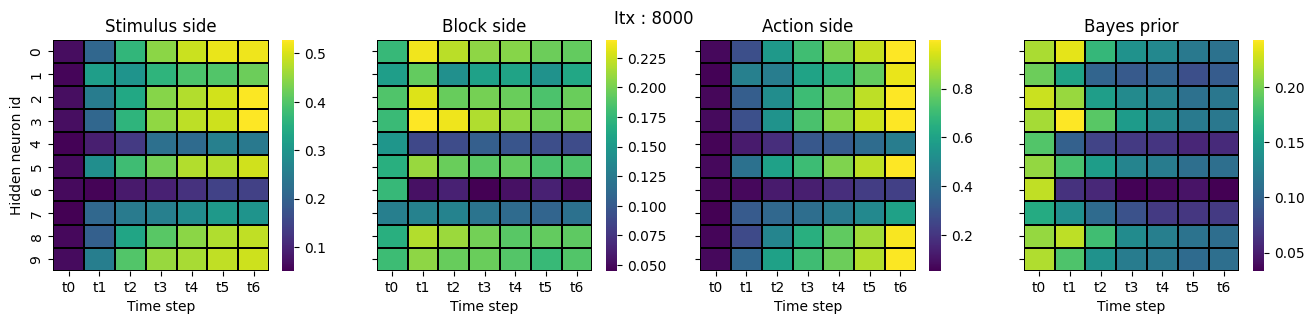

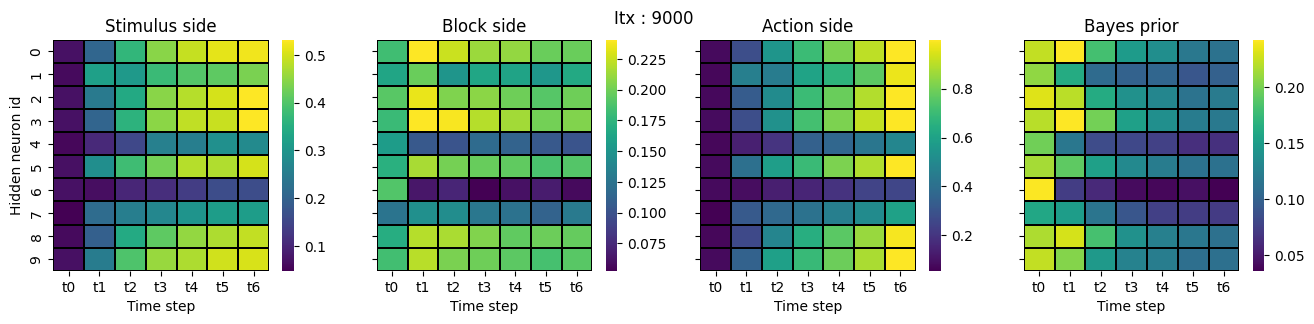

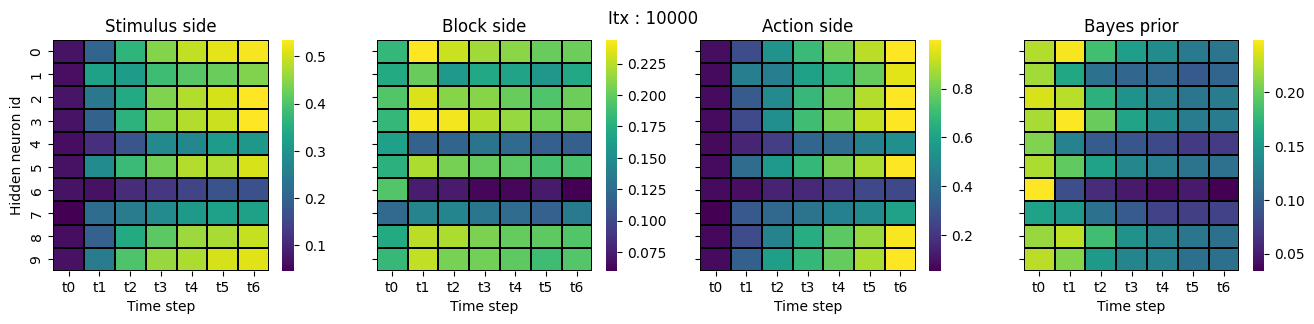

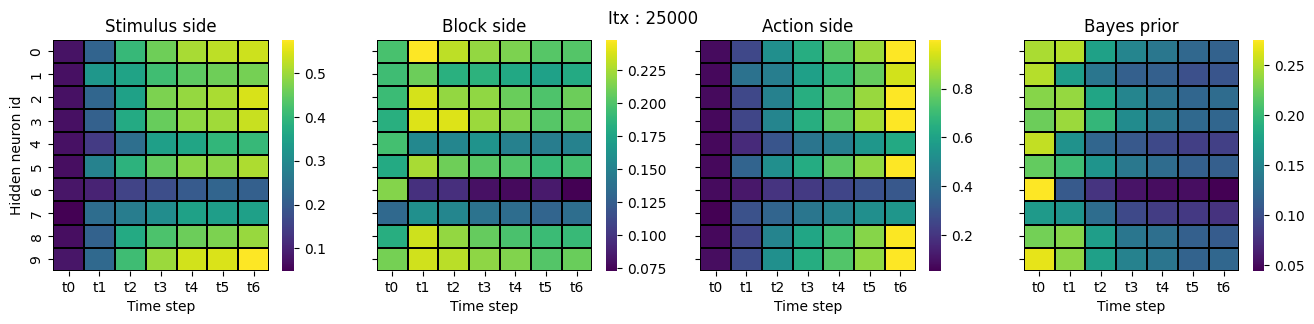

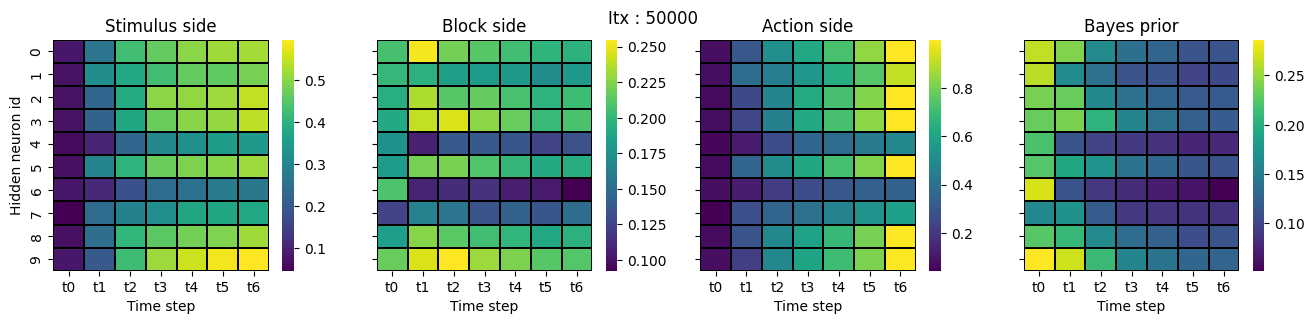

In [433]:
for k in rnn_mi_data.keys():
    (
        trial_side_mi,
        block_side_mi,
        action_side_mi,
        left_stim_mi,
        right_stim_mi,
        correct_action_prob_mi,
        filename,
    ) = rnn_mi_data[k]
    iteration_number = filename.rsplit("_10units_")[-1].rstrip(".pkl")
    plot_new_heatmaps(
        trial_side_mi, block_side_mi, action_side_mi, correct_action_prob_mi, iteration_number
    )

'../../ann-rnn-modified/data/fixed_time_stim_no_reward/rnn_ann_model_results_10units_50000.pkl'

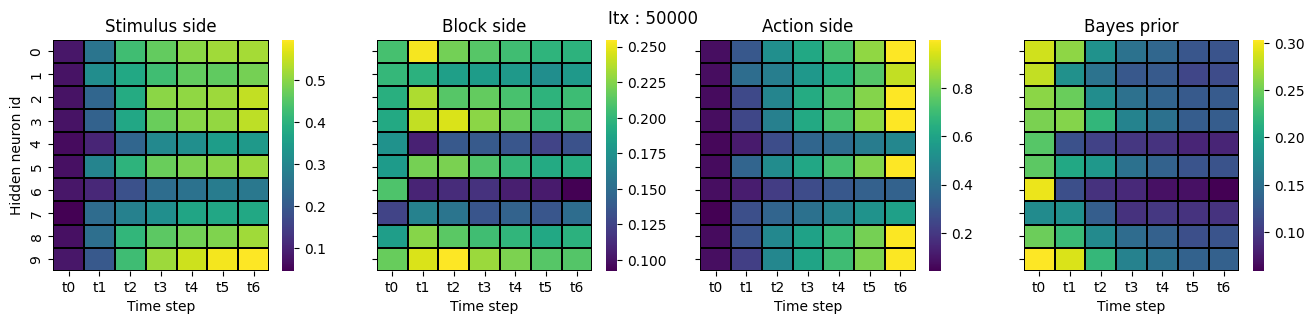

In [367]:
plot_new_heatmaps(trial_side_mi, block_side_mi, action_side_mi, bayes_prior_mi, 50000)

In [385]:
for idx, filename in enumerate(sorted_files[2:]):

    with open(filename, "rb") as f:
        rnn_data = pkl.load(f)
    rnn_data = rnn_data["session_data"]

    print(
        rnn_data[rnn_data.trial_end == 1.0].correct_action_taken.mean(),
        rnn_data[rnn_data.trial_end == 1.0].action_taken.mean(),
        rnn_data[rnn_data.action_taken == 1.0].correct_action_taken.mean(),
    )

0.090667255 0.0913323 0.99271846
0.3280869 0.3336289 0.9833887
0.5129683 0.52604747 0.97513694
0.6116161 0.6371093 0.9599861
0.6696963 0.7036134 0.9517958
0.70317 0.74351585 0.9457364
0.7304367 0.77654624 0.9406223
0.746176 0.79538906 0.9381271
0.8049213 0.8749723 0.9199392
0.82199067 0.89824873 0.9151037


In [386]:
new_files = glob(
    "../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_*"
)

In [387]:
new_files

['../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_1000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_3000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_10000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_5000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_50000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_2000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_25000.pkl',
 '../../ann-rnn-modified/data/fixed_time_stim_no_reward/bayesian_results_10units_4000.pkl']

In [392]:
for idx, filename in enumerate(new_files):

    with open(filename, "rb") as f:
        rnn_data = pkl.load(f)
    rnn_data = rnn_data["bayesian_actor_session_data"]

    print(
        rnn_data[rnn_data.trial_end == 1.0].correct_action_taken.mean(),
        rnn_data[rnn_data.trial_end == 1.0].action_taken.mean(),
        rnn_data[rnn_data.action_taken == 1.0].correct_action_taken.mean(),
    )

0.82036525 0.8721541 0.94061965
0.82036525 0.8721541 0.94061965
0.82036525 0.8721541 0.94061965
0.82036525 0.8721541 0.94061965
0.82036525 0.8721541 0.94061965
0.82036525 0.8721541 0.94061965
0.82036525 0.8721541 0.94061965
0.82036525 0.8721541 0.94061965


In [ ]:
b_discrete = []
for idx, filename in enumerate(sorted_files[2:]):

    with open(filename, "rb") as f:
        rnn_data = pkl.load(f)
    rnn_data = rnn_data["session_data"]

    # compute the bayesian prior
    tend = rnn_data[rnn_data["rnn_step_index"] == 6]
    side = tend["trial_side"].values
    action = tend["action_side"].values
    action[np.isnan(action)] = 0
    block_side = tend["block_side"].values
    bayesian_prior = optimal_Bayesian(action, side, 0.02).detach().numpy()
    bayes_discrete = discretize_bayes_signal(bayesian_prior, 5)
    b_discrete.append(bayes_discrete)

    

In [86]:
filename = sorted_files[-1]
with open(filename, "rb") as f:
    rnn_data = pkl.load(f)
rnn_data = rnn_data["session_data"]

# compute the bayesian prior
tend = rnn_data[rnn_data["rnn_step_index"] == 6]

In [87]:
# compute other mutual information stuff, (other than action)

trial_side_mi = np.zeros((7, 10))  # 7 steps, 10 neurons, mean and std
block_side_mi = np.zeros((7, 10))
left_stim_mi = np.zeros((7, 10))
right_stim_mi = np.zeros((7, 10))
bayes_prior_mi = np.zeros((7, 10))

X = np.concatenate(rnn_data.hidden_state)
Q = discretize_hidden_state(X.T, 30)

for x in range(0, 7):
    t_x = rnn_data.loc[
        rnn_data["rnn_step_index"] == x,
        [
            "block_side",
            "trial_within_session",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
            "correct_action_prob",
            "left_action_prob",
            "right_action_prob",
            "concordant_trial",
        ],
    ]

    indexes = t_x.index.values
    hidden_state_t_x = Q.T[indexes, :]

    # now just compute vanilla mutual information
    results_trial_side_x = computeMI(hidden_state_t_x, t_x["trial_side"].values)
    results_block_side_x = computeMI(hidden_state_t_x, t_x["block_side"].values)
    results_left_stimulus_x = computeMI(hidden_state_t_x, t_x["left_stimulus"].values)
    results_right_stimulus_x = computeMI(hidden_state_t_x, t_x["right_stimulus"].values)

    # dsc = t_x["correct_action_prob"] > 0.5
    # dsc = dsc.values
    # dsc = np.asarray(dsc, dtype="int")

    # replaced this with block prior
    trial_side_mi[x, :] = results_trial_side_x
    block_side_mi[x, :] = results_block_side_x
    left_stim_mi[x, :] = results_left_stimulus_x
    right_stim_mi[x, :] = results_right_stimulus_x

100%|██████████| 10/10 [00:00<00:00, 212.88it/s]


Text(0.5, 0.98, 'Itx : 99000')

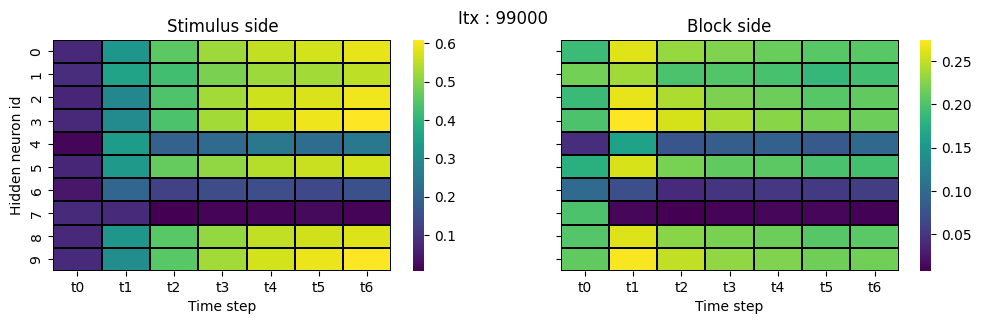

In [88]:
fig, ax = plt.subplots(figsize=(12, 3), ncols=2, sharex=True, sharey=True)

sns.heatmap(trial_side_mi.T, ax=ax[0], cmap="viridis", linecolor="k", linewidths=0.25)
sns.heatmap(block_side_mi.T, ax=ax[1], cmap="viridis", linecolor="k", linewidths=0.25)

ax[-1].set_xticklabels(labels=["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
for idx in range(ax.shape[-1]):
    ax[idx].set_xlabel("Time step")

ax[0].set_ylabel("Hidden neuron id")

ax[0].set_title("Stimulus side")
ax[1].set_title("Block side")
plt.suptitle(f"Itx : {99000}")

Text(0.5, 0.98, 'Itx : 0')

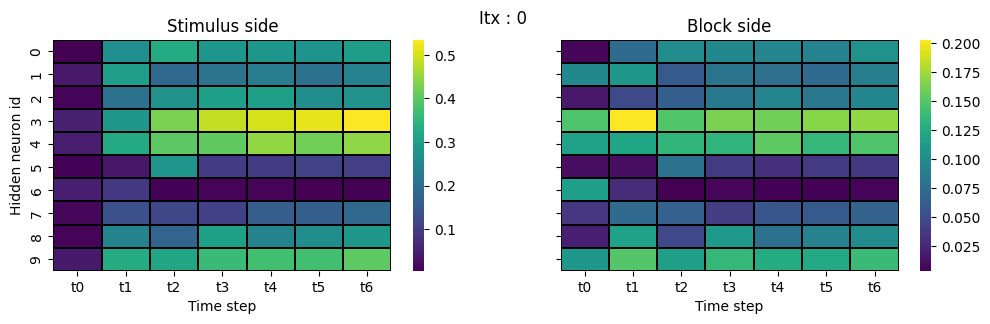

In [28]:
fig, ax = plt.subplots(figsize=(12, 3), ncols=2, sharex=True, sharey=True)

sns.heatmap(trial_side_mi.T, ax=ax[0], cmap="viridis", linecolor="k", linewidths=0.25)
sns.heatmap(block_side_mi.T, ax=ax[1], cmap="viridis", linecolor="k", linewidths=0.25)

ax[-1].set_xticklabels(labels=["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
for idx in range(ax.shape[-1]):
    ax[idx].set_xlabel("Time step")

ax[0].set_ylabel("Hidden neuron id")

ax[0].set_title("Stimulus side")
ax[1].set_title("Block side")
plt.suptitle(f"Itx : {0}")

Text(0.5, 0.98, 'Itx : 50000')

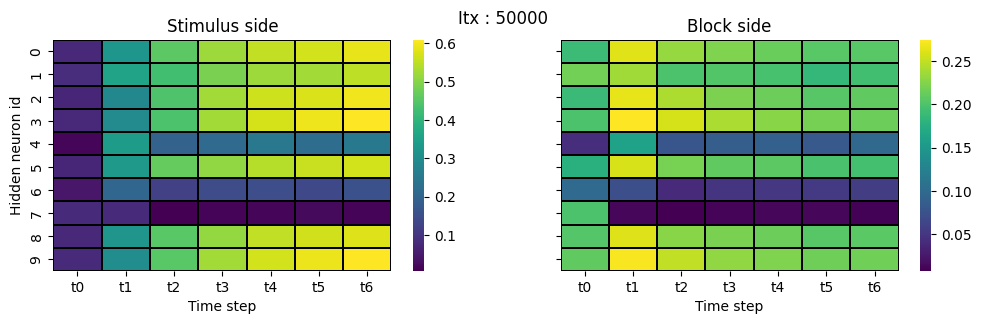

In [32]:
fig, ax = plt.subplots(figsize=(12, 3), ncols=2, sharex=True, sharey=True)

sns.heatmap(trial_side_mi.T, ax=ax[0], cmap="viridis", linecolor="k", linewidths=0.25)
sns.heatmap(block_side_mi.T, ax=ax[1], cmap="viridis", linecolor="k", linewidths=0.25)

ax[-1].set_xticklabels(labels=["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
for idx in range(ax.shape[-1]):
    ax[idx].set_xlabel("Time step")

ax[0].set_ylabel("Hidden neuron id")

ax[0].set_title("Stimulus side")
ax[1].set_title("Block side")
plt.suptitle(f"Itx : {50000}")

Text(0.5, 0.98, 'Itx : 3000')

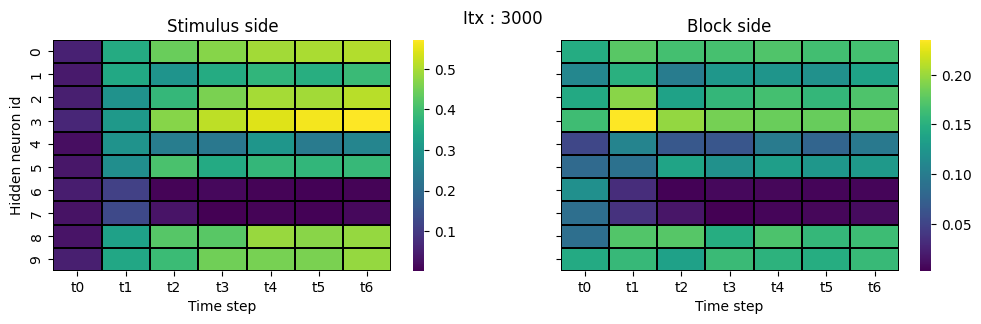

In [37]:
fig, ax = plt.subplots(figsize=(12, 3), ncols=2, sharex=True, sharey=True)

sns.heatmap(trial_side_mi.T, ax=ax[0], cmap="viridis", linecolor="k", linewidths=0.25)
sns.heatmap(block_side_mi.T, ax=ax[1], cmap="viridis", linecolor="k", linewidths=0.25)

ax[-1].set_xticklabels(labels=["t0", "t1", "t2", "t3", "t4", "t5", "t6"])
for idx in range(ax.shape[-1]):
    ax[idx].set_xlabel("Time step")

ax[0].set_ylabel("Hidden neuron id")

ax[0].set_title("Stimulus side")
ax[1].set_title("Block side")
plt.suptitle(f"Itx : {3000}")

In [6]:
filename = sorted_files[1]
with open(filename, "rb") as f:
    rnn_data = pkl.load(f)
rnn_data_1000 = rnn_data["session_data"]

filename = sorted_files[0]
with open(filename, "rb") as f:
    rnn_data = pkl.load(f)
rnn_data_0 = rnn_data["session_data"]

filename = sorted_files[-2]
with open(filename, "rb") as f:
    rnn_data = pkl.load(f)
rnn_data_50000 = rnn_data["session_data"]

filename = sorted_files[-1]
with open(filename, "rb") as f:
    rnn_data = pkl.load(f)
rnn_data_99000 = rnn_data["session_data"]

<Axes: xlabel='correct_action_prob', ylabel='Density'>

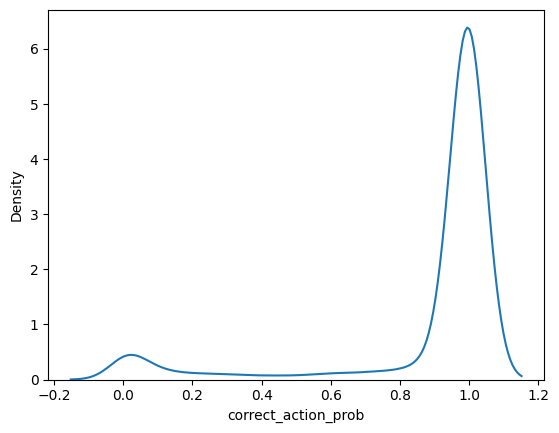

In [7]:
sns.kdeplot(rnn_data_99000[rnn_data_99000["trial_end"] == 1]["correct_action_prob"])

<Axes: xlabel='correct_action_prob', ylabel='Density'>

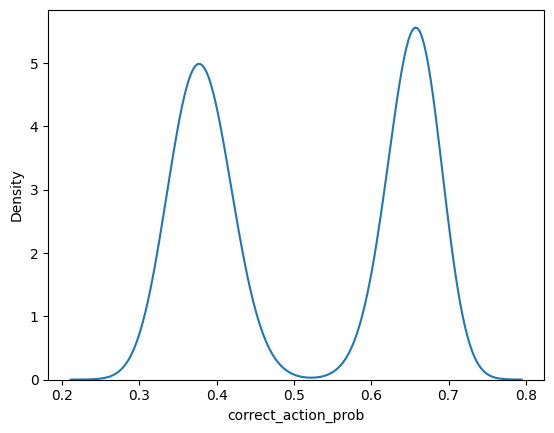

In [8]:
sns.kdeplot(rnn_data_0[rnn_data_0["trial_end"] == 1]["correct_action_prob"])

<Axes: xlabel='correct_action_prob', ylabel='Density'>

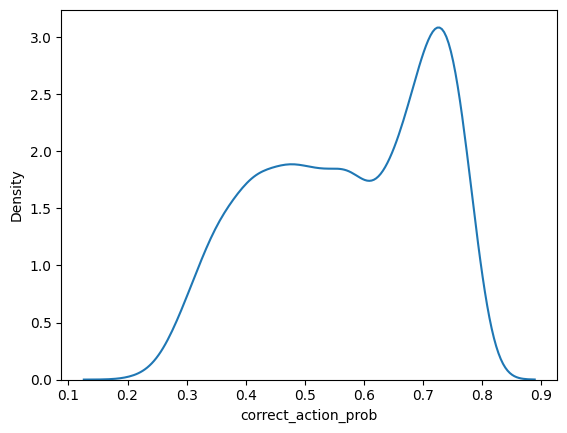

In [9]:
sns.kdeplot(rnn_data_1000[rnn_data_0["trial_end"] == 1]["correct_action_prob"])

<Axes: xlabel='correct_action_prob', ylabel='Density'>

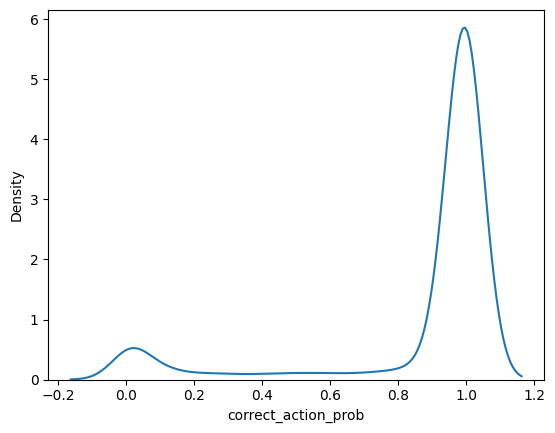

In [50]:
sns.kdeplot(rnn_data_50000[rnn_data_0["trial_end"] == 1]["correct_action_prob"])

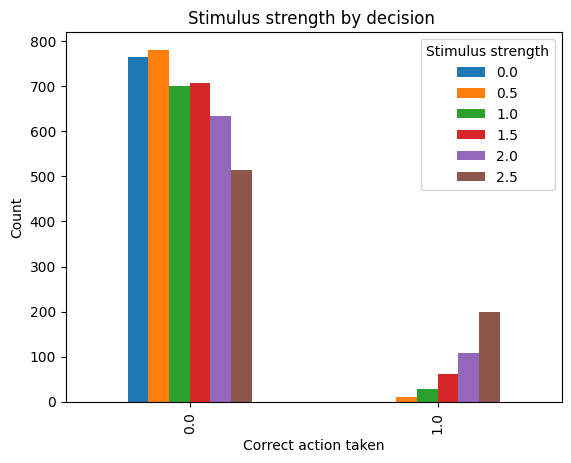

In [68]:
tend_3000 = rnn_data_3000[rnn_data_3000["trial_end"] == 1]
counts = (
    tend_3000.groupby("correct_action_taken")["trial_strength"]
    .value_counts()
    .unstack(fill_value=0)
)
counts.plot(kind="bar", stacked=False)
plt.title("Stimulus strength by decision ")
plt.ylabel("Count")
plt.xlabel("Correct action taken")
plt.legend(title="Stimulus strength")
plt.show()

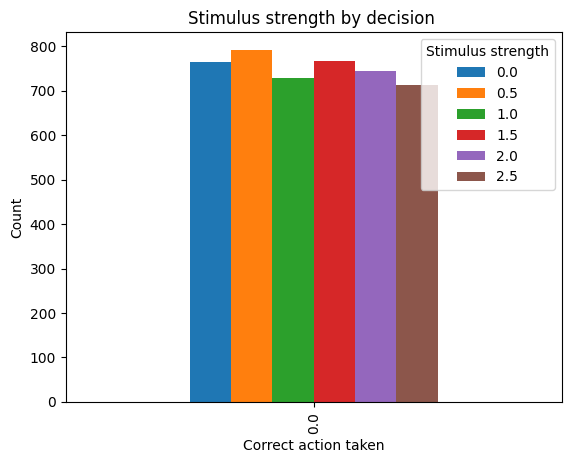

In [69]:
tend_0 = rnn_data_0[rnn_data_0["trial_end"] == 1]
counts = (
    tend_0.groupby("correct_action_taken")["trial_strength"].value_counts().unstack(fill_value=0)
)
counts.plot(kind="bar", stacked=False)
plt.title("Stimulus strength by decision ")
plt.ylabel("Count")
plt.xlabel("Correct action taken")
plt.legend(title="Stimulus strength")
plt.show()

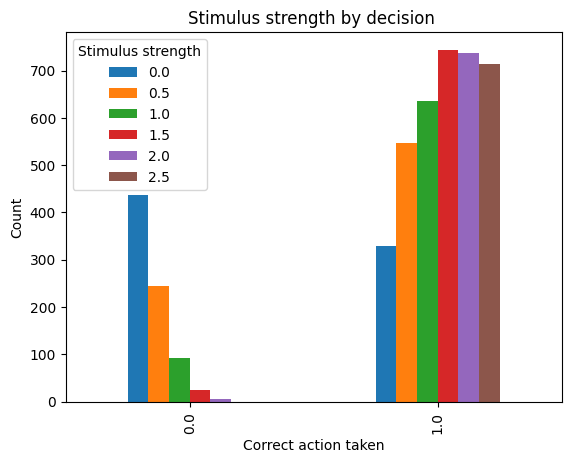

In [70]:
tend_50000 = rnn_data_50000[rnn_data_50000["trial_end"] == 1]
counts = (
    tend_50000.groupby("correct_action_taken")["trial_strength"]
    .value_counts()
    .unstack(fill_value=0)
)
counts.plot(kind="bar", stacked=False)
plt.title("Stimulus strength by decision ")
plt.ylabel("Count")
plt.xlabel("Correct action taken")
plt.legend(title="Stimulus strength")
plt.show()

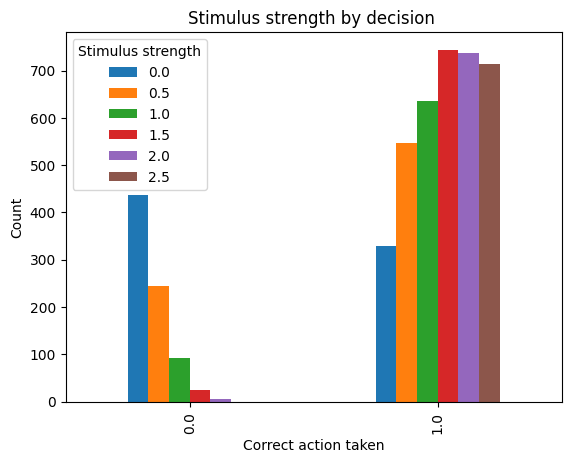

In [85]:
tend_99000 = rnn_data_99000[rnn_data_99000["trial_end"] == 1]
counts = (
    tend_99000.groupby("correct_action_taken")["trial_strength"]
    .value_counts()
    .unstack(fill_value=0)
)
counts.plot(kind="bar", stacked=False)
plt.title("Stimulus strength by decision ")
plt.ylabel("Count")
plt.xlabel("Correct action taken")
plt.legend(title="Stimulus strength")
plt.show()

In [ ]:
# TODO @tomorrow: need to figure out how to run them on the same environment?
# maybe because he runs it from a hook, it is the same environment?
# i don't think so though

Text(0, 0.5, 'Probabiity of correct action')

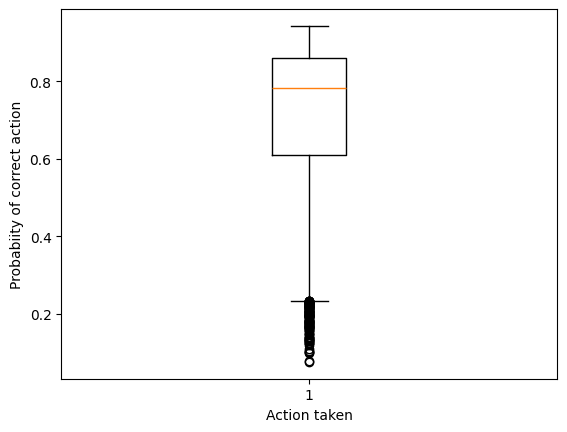

In [82]:
plt.boxplot(
    tend_3000["correct_action_prob"],
)
plt.xlabel("Action taken")
plt.ylabel("Probabiity of correct action")

Text(0, 0.5, 'Probabiity of correct action')

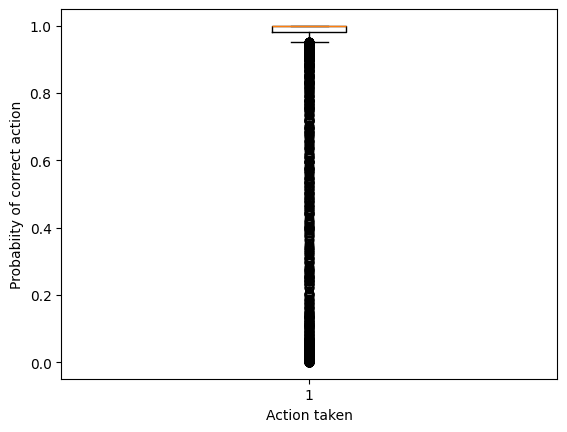

In [81]:
plt.boxplot(
    tend_50000["correct_action_prob"],
)
plt.xlabel("Action taken")
plt.ylabel("Probabiity of correct action")